**Analysis Steps**:
- Import ES trading data and clean ready for merging
- Import S&P E-mini Futures data and clean ready for merging
- Merge ES trading data into Futures data for analysis of daily settlement/returns
- Perform analysis on trading strategy:
    - Mean returns and volatility
    - Correlation/Beta with futures data (determine alpha)
    - Maximum drawdown, hit rate, sharpe ratio, etc. 
    - Plots
- Put together initial summary of findings, ready for "new" strategy investigation.

**1. Import and clean ES Trading Data 2020-2025**:

Import Libraries:

In [1]:
# Import libraries
import pandas as pd 
import numpy as np 
import math 
import statistics 
import matplotlib.pyplot as plt 
import yfinance as yf

#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

File import:

In [2]:
# Import and inspect ES_2020-2025.csv 
raw_df = pd.read_csv(r".\Signal_data\ES_2020-2025.csv", sep=";", engine="python") 

# Remove first row of NaN data
raw_df = raw_df.iloc[1:].reset_index(drop=True) 

# Remove the imported but empty last column 
raw_df = raw_df.iloc[:,:-1]

# Display current header 
raw_df.head() 

,Quarter,Model_Classification_ID,Entry_Date_ISO,ES_Entry_Price,Direction,Exit_Date_ISO,ES_Exit_Price
0,q3-20,q3-20_1,2020-08-10,"3347,00",-1.0,2020-08-11,"3350,25"
1,q3-20,q3-20_2,2020-08-11,"3350,25",1.0,2020-08-19,"3388,75"
2,q3-20,q3-20_3,2020-08-19,"3388,75",-1.0,2020-08-20,"3370,25"
3,q3-20,q3-20_4,2020-08-20,"3370,25",1.0,2020-08-28,"3488,00"
4,q4-20,q4-20_1,2020-09-25,"3243,50",1.0,2020-09-28,"3291,00"


Edit column values and tidy:

In [3]:
# Change column names
columns = ["Quarter", "Model_Classification_ID", "Entry_Date", "Entry_Price", "Signal", "Exit_Date", "Exit_Price"]
raw_df.columns = columns 

# Change prices to floats 
raw_df["Entry_Price"] = raw_df["Entry_Price"].str.replace(",", ".").astype(float) 
raw_df["Exit_Price"] = raw_df["Exit_Price"].str.replace(",", ".").astype(float)

# Change date strings to datetime 
raw_df["Entry_Date"] = pd.to_datetime(raw_df["Entry_Date"])
raw_df["Exit_Date"] = pd.to_datetime(raw_df["Exit_Date"])

# Drop Unnecessary columns
raw_df = raw_df.drop(columns=["Quarter", "Model_Classification_ID"])

# Review data formatting
raw_df.info()

# Rename trade data
trade_df = raw_df.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Entry_Date   117 non-null    datetime64[ns]
 1   Entry_Price  117 non-null    float64       
 2   Signal       117 non-null    float64       
 3   Exit_Date    117 non-null    datetime64[ns]
 4   Exit_Price   117 non-null    float64       
dtypes: datetime64[ns](2), float64(3)
memory usage: 4.7 KB


Review final trade data:

In [4]:
# Review final trade data
trade_df.head()

,Entry_Date,Entry_Price,Signal,Exit_Date,Exit_Price
0,2020-08-10,3347.00,-1.0,2020-08-11,3350.25
1,2020-08-11,3350.25,1.0,2020-08-19,3388.75
2,2020-08-19,3388.75,-1.0,2020-08-20,3370.25
3,2020-08-20,3370.25,1.0,2020-08-28,3488.00
4,2020-09-25,3243.50,1.0,2020-09-28,3291.00


**1b. Import and clean ES Trading Data 2025-2026**:

In [5]:
# Import data
SD_1_df = pd.read_csv(r".\Signal_data\Subset_data_cleaned.csv", index_col=0, parse_dates=True)

# Preview
SD_1_df 

,Signal,Entry_Price
index,,
2025-06-23,1,5964.00
2025-06-24,1,6078.00
2025-06-25,1,6144.75
2025-06-26,1,6144.75
2025-06-27,1,6197.50
...,...,...
2026-03-16,1,6608.50
2026-03-17,1,6700.00
2026-03-18,1,6722.50


In [6]:
# Import data
SD_2_df = pd.read_csv(r".\Signal_data\Q2_data_cleaned.csv", index_col=0, parse_dates=True)

# Preview
SD_2_df.head() 

,Signal,Entry_Price
index,,
2026-03-30,0,6380.00
2026-03-31,1,6385.25
2026-04-01,1,6562.00
2026-04-02,1,6618.50
2026-04-03,-1,6622.50


**2. Import and clean E-Mini Futures Data**

Market Data import:

In [7]:
# Comment out and pull from CSV 
ES_df = yf.download("ES=F", start=trade_df["Entry_Date"].iloc[0], end= (SD_2_df.index[-1] + pd.Timedelta(days=1)), auto_adjust=False) 
ES_df.columns = ES_df.columns.droplevel(1)
ES_df.reset_index().to_csv(r".\Market_data\ES_daily.csv", index=False)
print(ES_df)

[*********************100%***********************]  1 of 1 completed

Price       Adj Close    Close     High      Low     Open   Volume
Date                                                              
2020-08-10    3352.75  3352.75  3357.25  3329.00  3347.00  1201751
2020-08-11    3330.00  3330.00  3379.00  3319.50  3350.25  1733040
2020-08-12    3370.00  3370.00  3382.50  3326.25  3339.50  1408718
2020-08-13    3367.75  3367.75  3382.00  3357.50  3367.75  1205758
2020-08-14    3361.50  3361.50  3380.50  3350.00  3369.25  1084771
...               ...      ...      ...      ...      ...      ...
2026-06-08    7416.00  7416.00  7476.75  7355.50  7368.00  1821072
2026-06-09    7392.75  7392.75  7491.00  7247.25  7412.75  2505679
2026-06-10    7278.50  7278.50  7404.75  7256.00  7380.00  1851849
2026-06-11    7396.00  7396.00  7420.00  7232.25  7259.25  1851849
2026-06-12    7402.00  7402.00  7451.25  7374.75  7397.50   359243

[1471 rows x 6 columns]


Import market data from csv:

In [8]:
# Import data
ES_df = pd.read_csv(
    r".\Market_data\ES_daily.csv",
    index_col=0,
    parse_dates=True
)

**3. Merge Trading and Market Data for Analysis**:

In [13]:
# Create new Trading Strategy Dataframe
TS_df = ES_df.copy() 
TS_df.index = pd.to_datetime(TS_df.index)

# Add signal column
TS_df["Signal"] = 0 

# Fill trade signals from ES_2020-2025
for _, row in trade_df.iterrows():
    TS_df.loc[(TS_df.index >= row["Entry_Date"]) & (TS_df.index < row["Exit_Date"]), "Signal"] = row["Signal"]

# Fill trade signals from Subset data
common_idx = SD_1_df.index.intersection(TS_df.index)
TS_df.loc[common_idx, "Signal"] = SD_1_df.loc[common_idx, "Signal"]

# Fill trade signals from Q2 data
common_idx = SD_2_df.index.intersection(TS_df.index)
TS_df.loc[common_idx, "Signal"] = SD_2_df.loc[common_idx, "Signal"]

# Add Market Log Returns
TS_df["Log_Returns_Market"] = np.log(TS_df["Open"]/TS_df["Open"].shift(1))
TS_df["Log_Returns_Market"] = TS_df["Log_Returns_Market"].fillna(0)

# Add Strategy Log Returns
TS_df["Log_Returns_Strategy"] = TS_df["Signal"].shift(1) * TS_df["Log_Returns_Market"]
TS_df["Log_Returns_Strategy"] = TS_df["Log_Returns_Strategy"].fillna(0)

# Add Cum Returns 
TS_df["Cum_Market"] = np.exp(TS_df["Log_Returns_Market"].cumsum())
TS_df["Cum_Strategy"] = np.exp(TS_df["Log_Returns_Strategy"].cumsum())

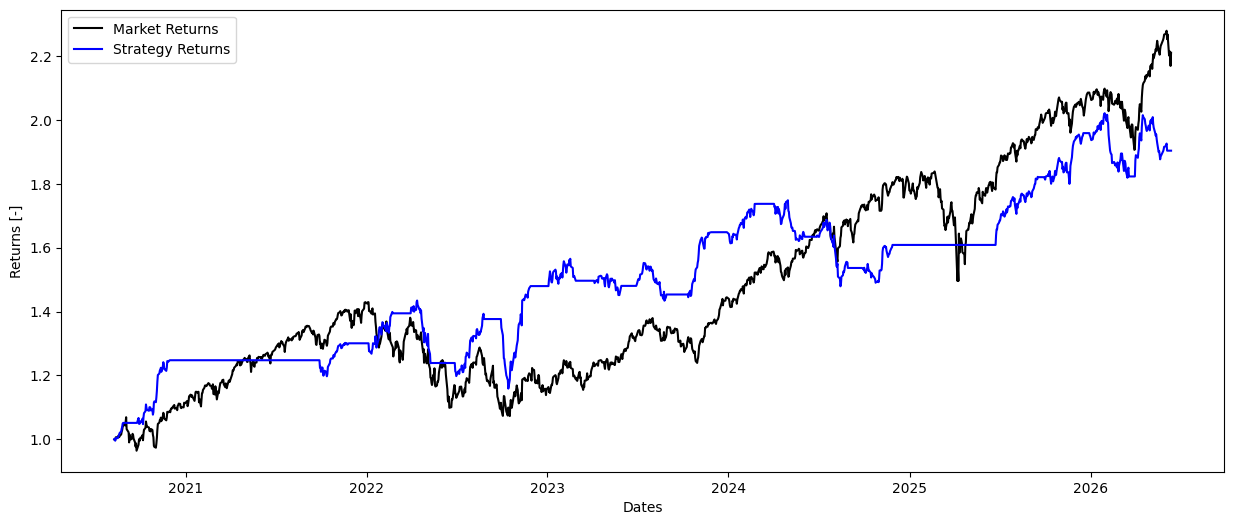

In [14]:
# Plot Results
plt.figure(figsize=(15,6))
plt.plot(TS_df.index, TS_df.Cum_Market, 'k-', label="Market Returns") 
plt.plot(TS_df.index, TS_df.Cum_Strategy, 'b-', label="Strategy Returns") 
plt.legend()
plt.xlabel("Dates") 
plt.ylabel("Returns [-]")
plt.show()

In [15]:
TS_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1471 entries, 2020-08-10 to 2026-06-12
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Adj Close             1471 non-null   float64
 1   Close                 1471 non-null   float64
 2   High                  1471 non-null   float64
 3   Low                   1471 non-null   float64
 4   Open                  1471 non-null   float64
 5   Volume                1471 non-null   int64  
 6   Signal                1471 non-null   int64  
 7   Log_Returns_Market    1471 non-null   float64
 8   Log_Returns_Strategy  1471 non-null   float64
 9   Cum_Market            1471 non-null   float64
 10  Cum_Strategy          1471 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 170.2 KB
